# Statistics of MeD-seq data

This notebook compares the number of DCM and CpG reads between MeD-seq samples.

## Input

- Statistics of MeD-seq samples (MeD-seq.statistics.txt)

## Output

- Figure 1b: Statistics from iPSCs
- Figure S3b: Statistics from iPSC propagation
- Figure S4c: Statistics from PGT differentiation

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy
from statsmodels.stats.multitest import multipletests

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sns.set_style("ticks")

In [2]:
# Directories: update these paths as needed
input_dir = "../Input"      # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Settings
labels = ["iPSC", "DE", "PGT"]              # custom labels
colors = ["#264653", "#E9C46A", "#E76F51"]  # colors to use
palette = dict(zip(labels, colors))         # palette for plots

In [3]:
stats = pd.read_csv(f"{input_dir}/MeD-seq.statistics.txt", sep="\t", header=0, index_col=0)
display(stats)

,Experiment,Condition,Sample,Total reads,DCM reads,CpG reads,Total million,DCM million,CpG million,DCM/CpG ratio,Genic DCM level,Correction factor
C4neg-1,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep1,42414674,1756919,40657755,42.414674,1.756919,40.657755,0.043212,0.000347,42.414674
C4neg-2,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep2,32645592,1431276,31214316,32.645592,1.431276,31.214316,0.045853,0.000328,32.645592
C4neg-3,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep3,34929672,1383492,33546180,34.929672,1.383492,33.546180,0.041241,0.000301,34.929672
C4-1,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep1,42715841,26629059,16086782,42.715841,26.629059,16.086782,1.655338,0.004367,55.308220
C4-2,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep2,48475994,20953967,27522027,48.475994,20.953967,27.522027,0.761353,0.003014,43.324689
C4-3,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep3,44165595,17234310,26931285,44.165595,17.234310,26.931285,0.639936,0.002737,35.839097
C6neg-1,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep1,36506398,1591859,34914539,36.506398,1.591859,34.914539,0.045593,0.000351,36.506398
C6neg-2,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep2,34477290,1273347,33203943,34.477290,1.273347,33.203943,0.038349,0.000286,34.477290
C6neg-3,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep3,34594914,1483964,33110950,34.594914,1.483964,33.110950,0.044818,0.000322,34.594914
C6-1,iPSC clones,iPSC C6 +dox,iPSCs +dox C6 rep1,38526918,16985836,21541082,38.526918,16.985836,21.541082,0.788532,0.003195,36.500221


## Figure 1b: Statistics from iPSCs

In [4]:
stats_clones = stats[stats["Experiment"] == "iPSC clones"].copy()
stats_clones["Label"] = ["C4 -dox"]*3 + ["C4 +dox"]*3 + ["C6 -dox"]*3 + ["C6 +dox"]*3
display(stats_clones)

,Experiment,Condition,Sample,Total reads,DCM reads,CpG reads,Total million,DCM million,CpG million,DCM/CpG ratio,Genic DCM level,Correction factor,Label
C4neg-1,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep1,42414674,1756919,40657755,42.414674,1.756919,40.657755,0.043212,0.000347,42.414674,C4 -dox
C4neg-2,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep2,32645592,1431276,31214316,32.645592,1.431276,31.214316,0.045853,0.000328,32.645592,C4 -dox
C4neg-3,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep3,34929672,1383492,33546180,34.929672,1.383492,33.546180,0.041241,0.000301,34.929672,C4 -dox
C4-1,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep1,42715841,26629059,16086782,42.715841,26.629059,16.086782,1.655338,0.004367,55.308220,C4 +dox
C4-2,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep2,48475994,20953967,27522027,48.475994,20.953967,27.522027,0.761353,0.003014,43.324689,C4 +dox
C4-3,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep3,44165595,17234310,26931285,44.165595,17.234310,26.931285,0.639936,0.002737,35.839097,C4 +dox
C6neg-1,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep1,36506398,1591859,34914539,36.506398,1.591859,34.914539,0.045593,0.000351,36.506398,C6 -dox
C6neg-2,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep2,34477290,1273347,33203943,34.477290,1.273347,33.203943,0.038349,0.000286,34.477290,C6 -dox
C6neg-3,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep3,34594914,1483964,33110950,34.594914,1.483964,33.110950,0.044818,0.000322,34.594914,C6 -dox
C6-1,iPSC clones,iPSC C6 +dox,iPSCs +dox C6 rep1,38526918,16985836,21541082,38.526918,16.985836,21.541082,0.788532,0.003195,36.500221,C6 +dox


In [5]:
results = []
for clone in ["C4", "C6"]:
    table = [[stats_clones.loc[stats_clones["Label"] == f"{clone} +dox", "DCM reads"].sum(),
              stats_clones.loc[stats_clones["Label"] == f"{clone} +dox", "CpG reads"].sum()],
             [stats_clones.loc[stats_clones["Label"] == f"{clone} -dox", "DCM reads"].sum(),
              stats_clones.loc[stats_clones["Label"] == f"{clone} -dox", "CpG reads"].sum()]]
    chi2, p, dof, expected = scipy.stats.chi2_contingency(table)
    results.append({"condition": clone, "chi2": chi2, "p": p})

results_df = pd.DataFrame(results)
reject, p_corr, _, _ = multipletests(results_df["p"], method="bonferroni")
results_df["p_bonferroni"] = p_corr
results_df["significant"] = reject
display(results_df)

,condition,chi2,p,p_bonferroni,significant
0,C4,5.720932e+07,0.0,0.0,True
1,C6,2.705221e+07,0.0,0.0,True


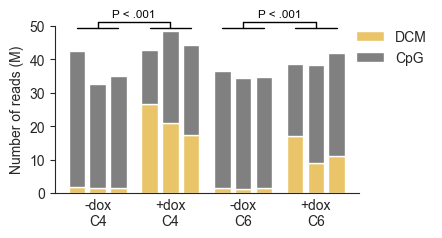

In [6]:
fig, ax = plt.subplots(figsize=(4.5, 2.5))

# Insert gaps between conditions
gaps = [3, 6, 9]
offset = 0
x_positions = []
for i in range(len(stats_clones)):
    if i in gaps:
        offset += 0.5
    x_positions.append(i + offset)

# Stacked barplot
ax.bar(x_positions, stats_clones["DCM million"], label="DCM", color="#e9c469")
ax.bar(x_positions, stats_clones["CpG million"], bottom=stats_clones["DCM million"], label="CpG", color="gray")

# Labels
ax.set(xlabel="", ylabel="Number of reads (M)", ylim=(0, 50))
ax.set_xticks([1, 4.5, 8, 11.5])
ax.set_xticklabels(["-dox\nC4", "+dox\nC4", "-dox\nC6", "+dox\nC6"], rotation=0)
ax.tick_params(axis="x", which="both", length=0)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.95,1.05))

# Add statistics
for x1, x2, y, label in [[1, 4.5, 51, "P < .001"], [8, 11.5, 51, "P < .001"]]:
    ax.plot((x1, x2), (y, y), color="black", linewidth=1, clip_on=False)                 # top horizontal line
    ax.plot((x1, x1), (y*0.97, y), color="black", linewidth=1, clip_on=False)            # left vertical line
    ax.plot((x2, x2), (y*0.97, y), color="black", linewidth=1, clip_on=False)            # right vertical line
    ax.plot((x1-1, x1+1), (y*0.97, y*0.97), color="black", linewidth=1, clip_on=False)   # bottom left horizontal line
    ax.plot((x2-1, x2+1), (y*0.97, y*0.97), color="black", linewidth=1, clip_on=False)   # bottom right horizontal line
    ax.text((x1+x2)/2, y*1.02, label, ha="center", va="bottom", color="black", fontsize="small")

# Save
sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure1b.svg", format="svg", bbox_inches="tight")
plt.show()

## Figure S3b: Statistics from iPSC propagation

In [7]:
stats_propagation = stats[(stats["Experiment"] == "iPSC propagation") | (stats["Condition"] == "iPSC C4 -dox")].copy()
stats_propagation["Label"] = ["-dox"]*3 + ["0h"]*2 + ["24h"]*2 + ["48h"]*2 + ["72h"]*2

stats_propagation["DCM percentage"] = stats_propagation["DCM million"] / stats_propagation["Total million"] * 100
stats_propagation["CpG percentage"] = stats_propagation["CpG million"] / stats_propagation["Total million"] * 100
display(stats_propagation)

,Experiment,Condition,Sample,Total reads,DCM reads,CpG reads,Total million,DCM million,CpG million,DCM/CpG ratio,Genic DCM level,Correction factor,Label,DCM percentage,CpG percentage
C4neg-1,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep1,42414674,1756919,40657755,42.414674,1.756919,40.657755,0.043212,0.000347,42.414674,-dox,4.142243,95.857757
C4neg-2,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep2,32645592,1431276,31214316,32.645592,1.431276,31.214316,0.045853,0.000328,32.645592,-dox,4.384286,95.615714
C4neg-3,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep3,34929672,1383492,33546180,34.929672,1.383492,33.546180,0.041241,0.000301,34.929672,-dox,3.960793,96.039207
T0-1,iPSC propagation,iPSC 0h,iPSCs CellTrace 0h rep1,473045,146485,326560,0.473045,0.146485,0.326560,0.448570,0.002402,0.522520,0h,30.966399,69.033601
T0-2,iPSC propagation,iPSC 0h,iPSCs CellTrace 0h rep2,424895,115254,309641,0.424895,0.115254,0.309641,0.372218,0.001947,0.380456,0h,27.125290,72.874710
T24-1,iPSC propagation,iPSC 24h,iPSCs CellTrace 24h rep1,370062,63320,306742,0.370062,0.063320,0.306742,0.206428,0.001316,0.223933,24h,17.110646,82.889354
T24-2,iPSC propagation,iPSC 24h,iPSCs CellTrace 24h rep2,433831,80944,352887,0.433831,0.080944,0.352887,0.229377,0.001548,0.308717,24h,18.657957,81.342043
T48-1,iPSC propagation,iPSC 48h,iPSCs CellTrace 48h rep1,722456,81646,640810,0.722456,0.081646,0.640810,0.127411,0.000941,0.312619,48h,11.301173,88.698827
T48-2,iPSC propagation,iPSC 48h,iPSCs CellTrace 48h rep2,436528,44152,392376,0.436528,0.044152,0.392376,0.112525,0.000828,0.166142,48h,10.114357,89.885643
T72-1,iPSC propagation,iPSC 72h,iPSCs CellTrace 72h rep1,413751,29769,383982,0.413751,0.029769,0.383982,0.077527,0.000612,0.116472,72h,7.194907,92.805093


In [8]:
results = []
for condition in ["0h", "24h", "48h", "72h"]:
    table = [[stats_propagation.loc[stats_propagation["Label"] == condition, "DCM reads"].sum(),
              stats_propagation.loc[stats_propagation["Label"] == condition, "CpG reads"].sum()],
             [stats_propagation.loc[stats_propagation["Label"] == "-dox", "DCM reads"].sum(),
              stats_propagation.loc[stats_propagation["Label"] == "-dox", "CpG reads"].sum()]]
    chi2, p, dof, expected = scipy.stats.chi2_contingency(table)
    results.append({"condition": condition, "chi2": chi2, "p": p})

results_df = pd.DataFrame(results)
reject, p_corr, _, _ = multipletests(results_df["p"], method="bonferroni")
results_df["p_bonferroni"] = p_corr
results_df["significant"] = reject
display(results_df)

,condition,chi2,p,p_bonferroni,significant
0,0h,1.334484e+06,0.0,0.0,True
1,24h,3.723468e+05,0.0,0.0,True
2,48h,1.271056e+05,0.0,0.0,True
3,72h,2.786939e+04,0.0,0.0,True


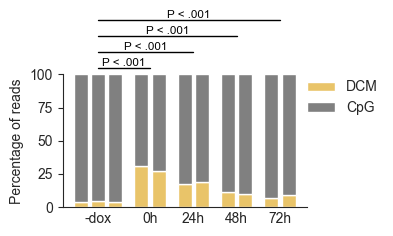

In [9]:
fig, ax = plt.subplots(figsize=(4, 2.8))

# Insert gaps between conditions
gaps = [3, 5, 7, 9]
offset = 0
x_positions = []
for i in range(len(stats_propagation)):
    if i in gaps:
        offset += 0.5
    x_positions.append(i + offset)

# Stacked barplot
ax.bar(x_positions, stats_propagation["DCM percentage"], label="DCM", color="#e9c469")
ax.bar(x_positions, stats_propagation["CpG percentage"], bottom=stats_propagation["DCM percentage"], label="CpG", color="gray")

# Labels
ax.set(xlabel="", ylabel="Percentage of reads", ylim=(0, 100))
ax.set_xticks([1, 4, 6.5, 9, 11.5])
ax.set_xticklabels(["-dox", "0h", "24h", "48h", "72h"], rotation=0)
ax.tick_params(axis="x", which="both", length=0)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.95,1.05))

# Add statistics
for x1, x2, y, label in [[1, 4, 105, "P < .001"], [1, 6.5, 117, "P < .001"],
                         [1, 9, 129, "P < .001"], [1, 11.5, 141, "P < .001"]]:
    ax.plot((x1, x2), (y, y), color="black", linewidth=1, clip_on=False)    # top horizontal line
    ax.text((x1+x2)/2, y, label, ha="center", va="bottom", color="black", fontsize="small")

# Save
sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure3b.svg", format="svg", bbox_inches="tight")
plt.show()

## Figure S4c: Statistics from PGT differentiation

In [10]:
stats_diff = stats[(stats["Experiment"] == "PGT differentiation") | (stats["Condition"] == "iPSC C4 -dox") | \
                   (stats["Condition"] == "iPSC C4 +dox")].copy()
stats_diff["Label"] = ["iPSC -dox"]*3 + ["iPSC dox"]*3 + ["iPSC chase"]*3 + ["DE chase"]*3 + ["DE dox"]*3 + ["PGT chase"]*3
stats_diff["Label"] = pd.Categorical(stats_diff["Label"], categories=["iPSC -dox", "iPSC chase", "iPSC dox", 
                                                                      "DE chase", "DE dox", "PGT chase"], ordered=True)
stats_diff = stats_diff.sort_values("Label")
display(stats_diff)

,Experiment,Condition,Sample,Total reads,DCM reads,CpG reads,Total million,DCM million,CpG million,DCM/CpG ratio,Genic DCM level,Correction factor,Label
C4neg-1,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep1,42414674,1756919,40657755,42.414674,1.756919,40.657755,0.043212,0.000347,42.414674,iPSC -dox
C4neg-2,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep2,32645592,1431276,31214316,32.645592,1.431276,31.214316,0.045853,0.000328,32.645592,iPSC -dox
C4neg-3,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep3,34929672,1383492,33546180,34.929672,1.383492,33.546180,0.041241,0.000301,34.929672,iPSC -dox
iPSC-c2,PGT differentiation,iPSC chase,iPSCs chase rep2,33699370,2686999,31012371,33.699370,2.686999,31.012371,0.086643,0.000717,7.161423,iPSC chase
iPSC-c1,PGT differentiation,iPSC chase,iPSCs chase rep1,34190998,2079124,32111874,34.190998,2.079124,32.111874,0.064746,0.000535,5.425211,iPSC chase
iPSC-c3,PGT differentiation,iPSC chase,iPSCs chase rep3,33967760,2335542,31632218,33.967760,2.335542,31.632218,0.073834,0.000595,5.991751,iPSC chase
C4-2,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep2,48475994,20953967,27522027,48.475994,20.953967,27.522027,0.761353,0.003014,43.324689,iPSC dox
C4-1,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep1,42715841,26629059,16086782,42.715841,26.629059,16.086782,1.655338,0.004367,55.308220,iPSC dox
C4-3,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep3,44165595,17234310,26931285,44.165595,17.234310,26.931285,0.639936,0.002737,35.839097,iPSC dox
DE-c1,PGT differentiation,DE chase,DE chase rep1,31324302,2308304,29015998,31.324302,2.308304,29.015998,0.079553,0.000571,5.306375,DE chase


In [11]:
results = []
for condition in ["iPSC chase", "iPSC dox", "DE chase", "DE dox", "PGT chase"]:
    table = [[stats_diff.loc[stats_diff["Label"] == condition, "DCM reads"].sum(),
              stats_diff.loc[stats_diff["Label"] == condition, "CpG reads"].sum()],
             [stats_diff.loc[stats_diff["Label"] == "iPSC -dox", "DCM reads"].sum(),
              stats_diff.loc[stats_diff["Label"] == "iPSC -dox", "CpG reads"].sum()]]
    chi2, p, dof, expected = scipy.stats.chi2_contingency(table)
    results.append({"condition": condition, "chi2": chi2, "p": p})

results_df = pd.DataFrame(results)
reject, p_corr, _, _ = multipletests(results_df["p"], method="bonferroni")
results_df["p_bonferroni"] = p_corr
results_df["significant"] = reject
display(results_df)

,condition,chi2,p,p_bonferroni,significant
0,iPSC chase,8.052429e+05,0.0,0.0,True
1,iPSC dox,5.720932e+07,0.0,0.0,True
2,DE chase,9.062496e+05,0.0,0.0,True
3,DE dox,3.429909e+07,0.0,0.0,True
4,PGT chase,5.255445e+06,0.0,0.0,True


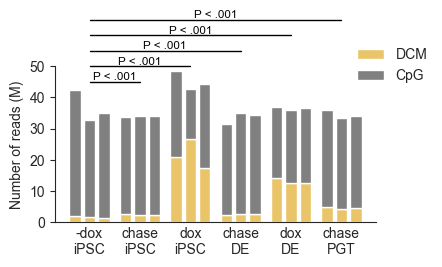

In [12]:
fig, ax = plt.subplots(figsize=(4.5, 3))

# Insert gaps between conditions
gaps = [3, 6, 9, 12, 15]
offset = 0
x_positions = []
for i in range(len(stats_diff)):
    if i in gaps:
        offset += 0.5
    x_positions.append(i + offset)

# Stacked barplot
ax.bar(x_positions, stats_diff["DCM million"], label="DCM", color="#e9c469")
ax.bar(x_positions, stats_diff["CpG million"], bottom=stats_diff["DCM million"], label="CpG", color="gray")

# Labels
ax.set(xlabel="", ylabel="Number of reads (M)", ylim=(0, 50))
ax.set_xticks([1, 4.5, 8, 11.5, 15, 18.5])
ax.set_xticklabels(["-dox\niPSC", "chase\niPSC", "dox\niPSC", "chase\nDE", "dox\nDE", "chase\nPGT"], rotation=0)
ax.tick_params(axis="x", which="both", length=0)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.9, 1.2))

# Add statistics
for x1, x2, y, label in [[1, 4.5, 45, "P < .001"], [1, 8, 50, "P < .001"],
                         [1, 11.5, 55, "P < .001"], [1, 15, 60, "P < .001"],
                         [1, 18.5, 65, "P < .001"]]:
    ax.plot((x1, x2), (y, y), color="black", linewidth=1, clip_on=False)    # top horizontal line
    ax.text((x1+x2)/2, y, label, ha="center", va="bottom", color="black", fontsize="small")

# Save
sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure4c.svg", format="svg", bbox_inches="tight")
plt.show()